# The DREAMS K-Complex Database

Data were acquired in a sleep laboratory of a belgium hospital using a digital 32-channel polygraph (BrainnetTM System of MEDATEC, Brussels, Belgium). They consist of 10 polysomnographic recordings coming from healthy subjects. Two EOG channels (P8-A1, P18-A1), three EEG channels (CZ-A1 or C3-A1, FP1-A1 and O1-A1) and one submental EMG channel were recorded. The standard European Data Format (EDF) was used for storing. The sampling frequency was 200Hz. A segment of 30 minutes of the central EEG channel was extracted from each whole-night recording for K-complexes scoring. These excerpts were given independently to two experts with the following recommendation regarding this annotation:
- K-complex must be a biphasic wave composed of a first negative sharp wave immediately followed by a slower positive component.
- It can occur isolated or by pair.
- It can be associated with spindles (before, after, or on it).
- Its duration should be at least 0.5s and no more than 1.5s.
- Its amplitude should be at least twice as high as the EEG background.
- The amplitude of the negative component should be at least 50% of the positive amplitude component.
- The minimum interval between successive K-complexes in slow wave sleep should be greater than 2s.
The corresponding whole night recordings were also previously scored in sleep stages according to the Rechtschaffen and Kales criteria, but no note of these stages quotations was given to the scorers. Unfortunately, the second expert has only annotated the first five excerpts.

Six files are available per excerpt (except for the five last excerpts, for which visual scoring 2 is absent):

* _excerpt.edf:_ corresponds to the polysomnographic recording in the European Data Format (EDF)
* _excerpt.txt:_ is a textual file containing, in first line, the name of the signal extracted (the central EEG) and then 1 column with the values (amplitudes in microvolt) of its samples. The number of samples depends on the sampling rate corresponding to the excerpt (see Database description)
* _Automatic_detection_excerpt.txt:_ is a textual file containing, in first line, the name of the detection and then 2 columns of numerical values. The first column contains time instants (in second) corresponding to the beginnings of the automatically detected micro-events (from the beginning of the excerpt), and the second one contains their durations (in second).
* _Visual_scoring1_excerpt.txt:_ is a textual file containing, in the first line, the name of the detection and then, 2 columns of numerical values. The first column contains time instants (in second) corresponding to the beginnings of the micro-events scored by the expert 1 (from the beginning of the excerpt), and the second one contains their durations (in second).
* _Visual_scoring2_excerpt.txt:_ is a textual file containing, in first line, the name of the detection and then 2 columns of numerical values. The first column contains time instants (in second) corresponding to the beginnings of the micro-events scored by the expert 2 (from the beginning of the excerpt), and the second one contains their durations (in second).
* _Hypnogram_excerpt.txt:_ is a textual file containing, in first line, the name "[hypnogram]" followed by one column of integer. These numerical values correspond to the sleep stage (one value per 5 sec) annotated by the expert according to the Rechtschaffen and Kales criteria.

# Set Up

In [18]:
import os
import numpy as np
import pandas as pd
import mne
from collections import Counter
from src.data.load_data import * #load_configuration_parameters, load_file
from src.data.preprocess import *
from src.base.localizator import * #get_candidates
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

## Helper functions

## Hypnogram conversion

In [11]:
# =============================================================================
# Hypnogram conversion (5s -> 30s epochs)
# =============================================================================
 
def convert_5s_to_30s_epochs(input_path, output_path):
    """
    Convert a 5-second scored hypnogram to 30-second epochs using
    majority vote.
 
    Parameters
    ----------
    input_path : str
        Path to the original hypnogram file (5s resolution).
        First line is a header (e.g., '[hypnogram]') and is skipped.
    output_path : str
        Path to write the 30s epoch hypnogram.
    """
    with open(input_path, 'r') as f:
        lines = f.readlines()
 
    # Skip header line and empty lines
    stages = []
    for line in lines:
        stripped = line.strip()
        if stripped == '' or stripped.startswith('['):
            continue
        stages.append(stripped)
 
    # Chunk into 30s epochs (6 x 5s = 30s)
    new_epochs = []
    for i in range(0, len(stages), 6):
        chunk = stages[i:i + 6]
        most_common = Counter(chunk).most_common(1)[0][0]
        new_epochs.append(most_common)
 
    # Write header + epochs
    with open(output_path, 'w') as f:
        for stage in new_epochs:
            f.write(f"{stage}\n")
 
    return new_epochs
 
 
def batch_convert_hypnograms(folder_path):
    """
    Convert all 5s hypnograms in a folder to 30s epochs.
    """
    for filename in os.listdir(folder_path):
        if (filename.startswith("Hypnogram_excerpt")
                and filename.endswith(".txt")
                and "_30s_epoch" not in filename):
            input_file = os.path.join(folder_path, filename)
            output_file = os.path.join(
                folder_path, filename.replace(".txt", "_30s_epoch.txt")
            )
            convert_5s_to_30s_epochs(input_file, output_file)
            print(f"Processed {filename} -> {os.path.basename(output_file)}")
 

## Annotation loading

In [5]:
# =============================================================================
# Annotation loading (with proper header handling)
# =============================================================================
 
def load_expert_annotations(filepath):
    """
    Load expert annotations from a text file.
 
    Parameters
    ----------
    filepath : str
        Path to the annotation file. First line is a header.
 
    Returns
    -------
    list of tuples
        Each tuple is (start_time, end_time) in seconds.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # Skip header
    annotations = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 2:
            continue
        start, duration = float(parts[0]), float(parts[1])
        end = start + duration
        annotations.append((start, end))
    return annotations
 
 
def load_stage2_epochs(hypnogram_path):
    """
    Load sleep stages from a hypnogram file.
 
    Parameters
    ----------
    hypnogram_path : str
        Path to the 30s-epoch hypnogram file.
        First line may be a header (e.g., '[hypnogram]') and is skipped.
 
    Returns
    -------
    list of str
        Sleep stage for each 30s epoch.
    """
    with open(hypnogram_path, 'r') as f:
        lines = f.readlines()
 
    # Skip header and empty lines
    stages = []
    for line in lines:
        stripped = line.strip()
        if stripped == '' or stripped.startswith('['):
            continue
        stages.append(stripped)
    return stages
 
 
def filter_annotations_by_stage2(filepath, stage2_epochs, epoch_duration=30):
    """
    Filter expert annotations to only those occurring during NREM Stage 2.
 
    Uses the midpoint of each annotation to determine which epoch it
    belongs to.
 
    Parameters
    ----------
    filepath : str
        Path to expert annotation file.
    stage2_epochs : list of str
        Sleep stage labels per 30s epoch.
    epoch_duration : int
        Duration of each epoch in seconds.
 
    Returns
    -------
    list of tuples
        Filtered annotations (start_time, end_time) in Stage 2 only.
    """
    annotations = load_expert_annotations(filepath)
    filtered = []
    for start, end in annotations:
        midpoint = (start + end) / 2
        epoch_idx = int(midpoint // epoch_duration)
        if epoch_idx < len(stage2_epochs) and stage2_epochs[epoch_idx] == "2":
            filtered.append((start, end))
    return filtered


## Candidate labeling

In [6]:
# =============================================================================
# Candidate labeling
# =============================================================================
 
def is_candidate_overlapping(candidate, annotations):
    """
    Check if a candidate overlaps with any expert annotation.
 
    Parameters
    ----------
    candidate : list
        [onset, duration] in seconds.
    annotations : list of tuples
        Each tuple is (start_time, end_time).
 
    Returns
    -------
    bool
        True if the candidate overlaps with at least one annotation.
    """
    c_start, c_dur = candidate
    c_end = c_start + c_dur
    for a_start, a_end in annotations:
        if a_start <= c_end and a_end >= c_start:
            return True
    return False
 
 
def label_candidates(candidates, expert1_annotations, expert2_annotations=None):
    """
    Label each candidate based on overlap with expert annotations.
 
    Parameters
    ----------
    candidates : list
        List of [onset, duration] candidates.
    expert1_annotations : list of tuples
        Expert 1 annotations (start, end).
    expert2_annotations : list of tuples or None
        Expert 2 annotations (start, end). None if not available.
 
    Returns
    -------
    labels : list of str
        'both', 'expert1', 'expert2', or 'none' for each candidate.
    match_stats : dict
        How many expert annotations were matched by any candidate.
    """
    labels = []
    matched_expert1 = set()
    matched_expert2 = set()
 
    has_expert2 = expert2_annotations is not None and len(expert2_annotations) > 0
 
    for candidate in candidates:
        in_exp1 = is_candidate_overlapping(candidate, expert1_annotations)
        in_exp2 = False
        if has_expert2:
            in_exp2 = is_candidate_overlapping(candidate, expert2_annotations)
 
        if in_exp1 and in_exp2:
            labels.append("both")
        elif in_exp1:
            labels.append("expert1")
        elif in_exp2:
            labels.append("expert2")
        else:
            labels.append("none")
 
        # Track which expert annotations were matched
        c_start, c_dur = candidate
        c_end = c_start + c_dur
        for idx, (a_start, a_end) in enumerate(expert1_annotations):
            if a_start <= c_end and a_end >= c_start:
                matched_expert1.add(idx)
        if has_expert2:
            for idx, (a_start, a_end) in enumerate(expert2_annotations):
                if a_start <= c_end and a_end >= c_start:
                    matched_expert2.add(idx)
 
    match_stats = {
        "expert1_total": len(expert1_annotations),
        "expert1_matched": len(matched_expert1),
    }
    if has_expert2:
        match_stats["expert2_total"] = len(expert2_annotations)
        match_stats["expert2_matched"] = len(matched_expert2)
 
    return labels, match_stats
 
 
def count_shared_expert_events(expert1_annotations, expert2_annotations, candidates):
    """
    Count events annotated by both experts and how many the localizator found.
 
    Parameters
    ----------
    expert1_annotations : list of tuples
        Expert 1 annotations (start, end).
    expert2_annotations : list of tuples
        Expert 2 annotations (start, end).
    candidates : list
        List of [onset, duration] candidates.
 
    Returns
    -------
    dict
        'shared_expert_events': overlapping annotations between experts.
        'shared_events_matched_by_candidates': how many were found.
    """
    shared_events = []
    used_exp2 = set()  # Avoid double-counting expert2 annotations
 
    for start1, end1 in expert1_annotations:
        for j, (start2, end2) in enumerate(expert2_annotations):
            if j in used_exp2:
                continue
            if start1 <= end2 and end1 >= start2:
                shared_start = min(start1, start2)
                shared_end = max(end1, end2)
                shared_events.append((shared_start, shared_end))
                used_exp2.add(j)
                break
 
    matched_by_candidates = 0
    for s_start, s_end in shared_events:
        for c_start, c_dur in candidates:
            c_end = c_start + c_dur
            if s_start <= c_end and s_end >= c_start:
                matched_by_candidates += 1
                break
 
    return {
        "shared_expert_events": len(shared_events),
        "shared_events_matched_by_candidates": matched_by_candidates,
    }

## Build dataframe for a given expert criterion

In [16]:
# =============================================================================
# Build df_overall for a given expert criterion
# =============================================================================
 
def build_df_overall(
    data_folder,
    expert_criterion,
    fs=200,
    window=2,
    timelocked2='min',
    cut_off_freqs=(0.3, 30),
):
    """
    Build the full dataframe for ML classification.
 
    Parameters
    ----------
    data_folder : str
        Path to the DREAMS dataset folder.
    expert_criterion : str
        One of 'expert1', 'expert2', 'any_both', 'both_same_time'.
    fs : int
        Sampling frequency.
    window : int
        Window length in seconds for KC extraction.
    timelocked2 : str
        Time-locking method ('min' or 'center').
    cut_off_freqs : tuple
        (low_freq, high_freq) for bandpass filter.
 
    Returns
    -------
    df_overall : pd.DataFrame
        Columns: sample1..sample{window*fs}, Subject, Label
    localizator_stats : dict
        Per-subject localizator statistics.
    """
    # Define which labels count as KC per criterion
    label_map = {
        'expert1': ['both', 'expert1'],
        'expert2': ['both', 'expert2'],
        'any_both': ['both', 'expert1', 'expert2'],
        'both_same_time': ['both'],
    }
    positive_labels = label_map[expert_criterion]
 
    # Define which subjects to use
    if expert_criterion in ['expert2', 'any_both', 'both_same_time']:
        subjects = list(range(1, 6))  # Need expert 2 -> only 1-5
    else:
        subjects = list(range(1, 11))  # Expert 1 scored all 10
 
    n_features = int(window * fs)
    columns = [f"sample{i+1}" for i in range(n_features)] + ["Subject", "Label"]
    all_events = []
 
    localizator_stats = {}
    mne.set_log_level('CRITICAL')
 
    for subject_num in subjects:
        print(f'--- Subject {subject_num} ---')
 
        # File paths
        edf_file = os.path.join(data_folder, f'excerpt{subject_num}.edf')
        annot_file1 = os.path.join(
            data_folder, f'Visual_scoring1_excerpt{subject_num}.txt'
        )
        annot_file2 = os.path.join(
            data_folder, f'Visual_scoring2_excerpt{subject_num}.txt'
        )
        scoring_file_30s = os.path.join(
            data_folder, f'Hypnogram_excerpt{subject_num}_30s_epoch.txt'
        )
 
        # Load and filter EEG
        raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
        raw_filtered = raw.copy().filter(
            l_freq=cut_off_freqs[0],
            h_freq=cut_off_freqs[1],
            picks='CZ-A1',
            verbose=False
        )
        x = raw_filtered.get_data(picks='CZ-A1').flatten()
        actual_fs = raw.info['sfreq']
 
        # Load expert annotations filtered to Stage 2
        stage2_epochs = load_stage2_epochs(scoring_file_30s)
        expert1_annotations = filter_annotations_by_stage2(
            annot_file1, stage2_epochs
        )
 
        expert2_annotations = []
        if subject_num <= 5:
            expert2_annotations = filter_annotations_by_stage2(
                annot_file2, stage2_epochs
            )
 
        # Run localizator
        candidates = get_candidates(
            signal=x,
            path_scoring=scoring_file_30s,
            sfreq=actual_fs,
            window_length=2,
        )
 
        # Label candidates
        labels, match_stats = label_candidates(
            candidates, expert1_annotations,
            expert2_annotations if subject_num <= 5 else None,
        )
 
        # Localizator stats
        localizator_stats[subject_num] = {
            'n_candidates': len(candidates),
            'match_stats': match_stats,
        }
 
        # Print localizator performance
        if match_stats['expert1_total'] > 0:
            exp1_rate = match_stats['expert1_matched'] / match_stats['expert1_total'] * 100
            print(f"  Expert 1 recall: {exp1_rate:.1f}% "
                  f"({match_stats['expert1_matched']}/{match_stats['expert1_total']})")
        if subject_num <= 5 and 'expert2_total' in match_stats:
            if match_stats['expert2_total'] > 0:
                exp2_rate = match_stats['expert2_matched'] / match_stats['expert2_total'] * 100
                print(f"  Expert 2 recall: {exp2_rate:.1f}% "
                      f"({match_stats['expert2_matched']}/{match_stats['expert2_total']})")
 
        if subject_num <= 5:
            shared = count_shared_expert_events(
                expert1_annotations, expert2_annotations, candidates
            )
            print(f"  Shared expert events: {shared['shared_expert_events']}, "
                  f"found by localizator: {shared['shared_events_matched_by_candidates']}")
 
        n_kc = sum(1 for lab in labels if lab in positive_labels)
        n_nokc = len(labels) - n_kc
        print(f"  Candidates: {len(candidates)} (KC={n_kc}, noKC={n_nokc})")
 
        # Extract KC events
        for cand, lab in zip(candidates, labels):
            try:
                cand_dict = {'onset': cand[0], 'duration': cand[1]}
                cand_event = get_KC_event(
                    cand_dict, x, sfreq=actual_fs,
                    window=window, timelocked2=timelocked2
                )[0].tolist()
            except Exception as e:
                continue
 
            if len(cand_event) != n_features:
                continue
 
            cand_lab = 'KC' if lab in positive_labels else 'noKC'
            all_events.append(cand_event + [subject_num, cand_lab])
 
    df_overall = pd.DataFrame(data=all_events, columns=columns)
    df_overall.dropna(subset=['Label'], inplace=True)
 
    print(f"\n{'='*50}")
    print(f"Criterion: {expert_criterion}")
    print(f"Total samples: {len(df_overall)}")
    print(f"  KC:   {(df_overall['Label']=='KC').sum()}")
    print(f"  noKC: {(df_overall['Label']=='noKC').sum()}")
    print(f"Subjects: {sorted(df_overall['Subject'].unique())}")
    print(f"{'='*50}")
 
    return df_overall, localizator_stats

# Run DREAMS dataset

In [12]:
data_folder = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm"
# Convert hypnograms (run once)
batch_convert_hypnograms(data_folder) 

Processed Hypnogram_excerpt1.txt -> Hypnogram_excerpt1_30s_epoch.txt
Processed Hypnogram_excerpt10.txt -> Hypnogram_excerpt10_30s_epoch.txt
Processed Hypnogram_excerpt2.txt -> Hypnogram_excerpt2_30s_epoch.txt
Processed Hypnogram_excerpt3.txt -> Hypnogram_excerpt3_30s_epoch.txt
Processed Hypnogram_excerpt4.txt -> Hypnogram_excerpt4_30s_epoch.txt
Processed Hypnogram_excerpt5.txt -> Hypnogram_excerpt5_30s_epoch.txt
Processed Hypnogram_excerpt6.txt -> Hypnogram_excerpt6_30s_epoch.txt
Processed Hypnogram_excerpt7.txt -> Hypnogram_excerpt7_30s_epoch.txt
Processed Hypnogram_excerpt8.txt -> Hypnogram_excerpt8_30s_epoch.txt
Processed Hypnogram_excerpt9.txt -> Hypnogram_excerpt9_30s_epoch.txt


## Detect events with localizator

In [17]:
#  Build df_overall for each criterion
results = {}
for criterion in ['expert1', 'expert2', 'any_both', 'both_same_time']:
    print(f"\n{'#'*60}")
    print(f"# {criterion}")
    print(f"{'#'*60}\n")
    df, stats = build_df_overall(
        data_folder,
        expert_criterion=criterion,
        fs=200,
        window=2,
        timelocked2='min',
        cut_off_freqs=(0.3, 30),
    )
    results[criterion] = {'df': df, 'stats': stats}


############################################################
# expert1
############################################################

--- Subject 1 ---


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP, POS
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Physical range is not defined in following channels:
PCPAP, POS
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)


  Expert 1 recall: 94.7% (18/19)
  Expert 2 recall: 100.0% (6/6)
  Shared expert events: 5, found by localizator: 5
  Candidates: 613 (KC=23, noKC=590)
--- Subject 2 ---


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)


  Expert 1 recall: 100.0% (27/27)
  Expert 2 recall: 100.0% (3/3)
  Shared expert events: 3, found by localizator: 3
  Candidates: 547 (KC=36, noKC=511)
--- Subject 3 ---


...

  Expert 1 recall: 100.0% (11/11)
  Expert 2 recall: 100.0% (2/2)
  Shared expert events: 2, found by localizator: 2
  Candidates: 289 (KC=3, noKC=286)
--- Subject 4 ---


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)


  Expert 1 recall: 95.9% (47/49)
  Expert 2 recall: 100.0% (6/6)
  Shared expert events: 6, found by localizator: 6
  Candidates: 525 (KC=8, noKC=517)
--- Subject 5 ---


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_19980\3905756283.py:76: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)


  Expert 1 recall: 100.0% (38/38)
  Expert 2 recall: 94.4% (17/18)
  Shared expert events: 12, found by localizator: 12
  Candidates: 637 (KC=17, noKC=620)

Criterion: both_same_time
Total samples: 2608
  KC:   36
  noKC: 2572
Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Detect KC vs noKC with classificator

**DREAMS KC Classification Experiments**

Four experiments:
  1) _External test:_ model trained on original dataset (Forcato2020 et al.), tested on DREAMS
  2) _New model:_ trained and evaluated within DREAMS using GroupKFold

Each experiment is run with _two labeling criteria_:
  1) **expert1** (10 subjects, 285 KC)
  2) **any_both** (5 subjects, 210 KC)

In [19]:
# =============================================================================
# Shared utilities
# =============================================================================

def scale_values(X):
    """Row-wise (per-epoch) z-score normalization."""
    scaler = StandardScaler()
    scaler.fit(X.values.T)
    X_scaled = scaler.transform(X.values.T)
    X_scaled = pd.DataFrame(data=X_scaled.T, columns=X.columns)
    return X_scaled


def compute_metrics(y_true, y_pred, positive_label="KC"):
    """Compute binary classification metrics."""
    TP = ((y_true == positive_label) & (y_pred == positive_label)).sum()
    TN = ((y_true != positive_label) & (y_pred != positive_label)).sum()
    FP = ((y_true != positive_label) & (y_pred == positive_label)).sum()
    FN = ((y_true == positive_label) & (y_pred != positive_label)).sum()

    recall = TP / (TP + FN) if (TP + FN) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'recall': recall, 'specificity': specificity,
        'accuracy': accuracy, 'precision': precision, 'f1': f1,
    }


def print_metrics(metrics, title=""):
    """Pretty-print a metrics dictionary."""
    if title:
        print(f"\n{'='*60}")
        print(f"  {title}")
        print(f"{'='*60}")
    print(f"  TP={metrics['TP']}, TN={metrics['TN']}, "
          f"FP={metrics['FP']}, FN={metrics['FN']}")
    print(f"  Recall:      {metrics['recall']*100:.2f}%")
    print(f"  Specificity: {metrics['specificity']*100:.2f}%")
    print(f"  Accuracy:    {metrics['accuracy']*100:.2f}%")
    print(f"  Precision:   {metrics['precision']*100:.2f}%")
    print(f"  F1:          {metrics['f1']*100:.2f}%")

### Running model trained with Forcato

In [20]:
# =============================================================================
# External test (train on original, test on DREAMS)
# =============================================================================

def external_test(df_original, df_dreams, criterion_name):
    """
    Train SVC on all Flag=1 samples from the original dataset and
    evaluate on the full DREAMS dataset.

    Parameters
    ----------
    df_original : pd.DataFrame
        Original dataset with Flag, Label, Subject, etc.
    df_dreams : pd.DataFrame
        DREAMS dataset with Label, Subject, sample1..sample400.
    criterion_name : str
        Name of the labeling criterion (for display).

    Returns
    -------
    metrics : dict
        Classification metrics on DREAMS.
    y_pred : np.ndarray
        Predictions for each DREAMS sample.
    """
    print(f"\n{'#'*60}")
    print(f"# EXTERNAL TEST: trained on original, tested on DREAMS")
    print(f"# Criterion: {criterion_name}")
    print(f"{'#'*60}")

    meta_cols_original = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    meta_cols_dreams = ['Subject', 'Label']

    feature_cols_original = [c for c in df_original.columns if c not in meta_cols_original]
    feature_cols_dreams = [c for c in df_dreams.columns if c not in meta_cols_dreams]

    # Train on all Flag=1 from original dataset
    idx_model = df_original[df_original['Flag'] == 1].index
    X_train = df_original.loc[idx_model, feature_cols_original]
    y_train = df_original.loc[idx_model, 'Label']
    X_train_scaled = scale_values(X_train)

    # Test on full DREAMS dataset
    X_test = df_dreams[feature_cols_dreams]
    y_test = df_dreams['Label']
    X_test_scaled = scale_values(X_test)

    print(f"  Train: {len(X_train)} samples from original dataset (Flag=1)")
    print(f"  Test:  {len(X_test)} samples from DREAMS "
          f"(KC={(y_test=='KC').sum()}, noKC={(y_test=='noKC').sum()})")

    # Train and predict
    clf = SVC(C=2.0, class_weight='balanced')
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Metrics
    metrics = compute_metrics(y_test, y_pred)
    print_metrics(metrics, f"External test results ({criterion_name})")

    # Per-subject breakdown
    print(f"\n  Per-subject breakdown:")
    for subj in sorted(df_dreams['Subject'].unique()):
        mask = df_dreams['Subject'] == subj
        subj_metrics = compute_metrics(y_test[mask], pd.Series(y_pred[mask.values]))
        n_kc = (y_test[mask] == 'KC').sum()
        n_nokc = (y_test[mask] == 'noKC').sum()
        print(f"    Subject {subj} (KC={n_kc}, noKC={n_nokc}): "
              f"Recall={subj_metrics['recall']*100:.1f}%, "
              f"Spec={subj_metrics['specificity']*100:.1f}%, "
              f"F1={subj_metrics['f1']*100:.1f}%")

    return metrics, y_pred

In [27]:
df_original = pd.read_csv(r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\reports\models\overall_results_timelocked2min_COMPLETE.csv').drop(columns=['Unnamed: 0'])

In [25]:
df_dreams_expert1 = results['expert1']['df']
df_dreams_any_both = results['any_both']['df']


In [28]:
ext_metrics_exp1, ext_pred_exp1 = external_test(
    df_original, df_dreams_expert1, "expert1"
)
ext_metrics_any, ext_pred_any = external_test(
    df_original, df_dreams_any_both, "any_both"
)


############################################################
# EXTERNAL TEST: trained on original, tested on DREAMS
# Criterion: expert1
############################################################
  Train: 480 samples from original dataset (Flag=1)
  Test:  5329 samples from DREAMS (KC=285, noKC=5044)

  External test results (expert1)
  TP=155, TN=4329, FP=715, FN=130
  Recall:      54.39%
  Specificity: 85.82%
  Accuracy:    84.14%
  Precision:   17.82%
  F1:          26.84%

  Per-subject breakdown:
    Subject 1 (KC=23, noKC=588): Recall=52.2%, Spec=87.8%, F1=22.4%
    Subject 2 (KC=36, noKC=511): Recall=0.0%, Spec=0.0%, F1=0.0%
    Subject 3 (KC=16, noKC=273): Recall=0.0%, Spec=0.0%, F1=0.0%
    Subject 4 (KC=72, noKC=452): Recall=0.0%, Spec=0.0%, F1=0.0%
    Subject 5 (KC=57, noKC=580): Recall=0.0%, Spec=0.0%, F1=0.0%
    Subject 6 (KC=30, noKC=364): Recall=0.0%, Spec=0.0%, F1=0.0%
    Subject 7 (KC=18, noKC=416): Recall=0.0%, Spec=0.0%, F1=0.0%
    Subject 8 (KC=5, noKC=478): 

### Running same pipeline used with Forcato

In [ ]:
# =============================================================================
# New model within DREAMS (GroupKFold)
# =============================================================================

def dreams_groupkfold(df_dreams, criterion_name, n_splits=5):
    """
    Train and evaluate SVC within DREAMS using GroupKFold.

    Parameters
    ----------
    df_dreams : pd.DataFrame
        DREAMS dataset with Label, Subject, sample1..sample400.
    criterion_name : str
        Name of the labeling criterion (for display).
    n_splits : int
        Number of GroupKFold splits. Default 5 (appropriate for 5-10 subjects).

    Returns
    -------
    fold_metrics : dict
        Per-fold and aggregated metrics.
    df_results : pd.DataFrame
        DREAMS samples with out-of-fold predictions.
    """
    print(f"\n{'#'*60}")
    print(f"# DREAMS GroupKFold: train and evaluate within DREAMS")
    print(f"# Criterion: {criterion_name}")
    print(f"{'#'*60}")

    meta_cols = ['Subject', 'Label']
    feature_cols = [c for c in df_dreams.columns if c not in meta_cols]

    X = df_dreams[feature_cols]
    y = df_dreams['Label']
    groups = df_dreams['Subject']
    X_scaled = scale_values(X)

    n_subjects = df_dreams['Subject'].nunique()
    actual_splits = min(n_splits, n_subjects)
    print(f"  Samples: {len(X)} (KC={(y=='KC').sum()}, noKC={(y=='noKC').sum()})")
    print(f"  Subjects: {n_subjects}, Folds: {actual_splits}")

    gk = GroupKFold(n_splits=actual_splits)

    # Storage
    oof_pred = pd.Series(index=X.index, dtype=object)
    all_metrics = {'TP': [], 'TN': [], 'FP': [], 'FN': [],
                   'recall': [], 'specificity': [], 'accuracy': [], 'f1': []}

    for fold_idx, (train_idx, test_idx) in enumerate(
        gk.split(X_scaled, y, groups=groups)
    ):
        X_train = X_scaled.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_test = X_scaled.iloc[test_idx]
        y_test = y.iloc[test_idx]

        test_subjects = groups.iloc[test_idx].unique()

        clf = SVC(C=2.0, class_weight='balanced')
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        oof_pred.iloc[test_idx] = y_pred

        m = compute_metrics(y_test, y_pred)
        for key in all_metrics:
            all_metrics[key].append(m[key])

        n_kc_train = (y_train == 'KC').sum()
        n_kc_test = (y_test == 'KC').sum()
        print(f"  Fold {fold_idx+1}: Train={len(train_idx)} (KC={n_kc_train}), "
              f"Test={len(test_idx)} (KC={n_kc_test}), "
              f"Subjects={list(test_subjects)} -> "
              f"Recall={m['recall']*100:.1f}%, F1={m['f1']*100:.1f}%")

    # Aggregated metrics
    print(f"\n  --- Average metrics (± std) ---")
    for metric_name in ['recall', 'specificity', 'accuracy', 'f1']:
        vals = all_metrics[metric_name]
        print(f"  {metric_name.capitalize():12s}: "
              f"{np.mean(vals)*100:.2f}% ± {np.std(vals)*100:.2f}%")

    # Global metrics (sum confusion matrix)
    global_TP = sum(all_metrics['TP'])
    global_TN = sum(all_metrics['TN'])
    global_FP = sum(all_metrics['FP'])
    global_FN = sum(all_metrics['FN'])
    global_recall = global_TP / (global_TP + global_FN) if (global_TP + global_FN) else 0
    global_spec = global_TN / (global_TN + global_FP) if (global_TN + global_FP) else 0
    global_acc = (global_TP + global_TN) / (global_TP + global_TN + global_FP + global_FN)
    global_f1 = 2 * global_TP / (2 * global_TP + global_FP + global_FN) if (2 * global_TP + global_FP + global_FN) else 0

    print(f"\n  --- Global metrics (summed confusion matrix) ---")
    print(f"  TP={global_TP}, TN={global_TN}, FP={global_FP}, FN={global_FN}")
    print(f"  Recall:      {global_recall*100:.2f}%")
    print(f"  Specificity: {global_spec*100:.2f}%")
    print(f"  Accuracy:    {global_acc*100:.2f}%")
    print(f"  F1:          {global_f1*100:.2f}%")

    # Build results dataframe
    df_results = df_dreams[meta_cols].copy()
    df_results['y_pred'] = oof_pred

    return all_metrics, df_results

In [30]:
# --- Experiment B: GroupKFold within DREAMS ---
gkf_metrics_exp1, gkf_results_exp1 = dreams_groupkfold(
    df_dreams_expert1, "expert1", n_splits=5
)
gkf_metrics_any, gkf_results_any = dreams_groupkfold(
    df_dreams_any_both, "any_both", n_splits=5
)


############################################################
# DREAMS GroupKFold: train and evaluate within DREAMS
# Criterion: expert1
############################################################
  Samples: 5329 (KC=285, noKC=5044)
  Subjects: 10, Folds: 5
  Fold 1: Train=4258 (KC=262), Test=1071 (KC=23), Subjects=[np.int64(3), np.int64(9)] -> Recall=60.9%, F1=33.7%
  Fold 2: Train=4298 (KC=198), Test=1031 (KC=87), Subjects=[np.int64(5), np.int64(6)] -> Recall=54.0%, F1=56.0%
  Fold 3: Train=4267 (KC=246), Test=1062 (KC=39), Subjects=[np.int64(7), np.int64(10)] -> Recall=61.5%, F1=48.5%
  Fold 4: Train=4235 (KC=257), Test=1094 (KC=28), Subjects=[np.int64(1), np.int64(8)] -> Recall=46.4%, F1=31.0%
  Fold 5: Train=4258 (KC=177), Test=1071 (KC=108), Subjects=[np.int64(2), np.int64(4)] -> Recall=40.7%, F1=51.2%

  --- Average metrics (± std) ---
  Recall      : 52.72% ± 8.11%
  Specificity : 96.48% ± 0.79%
  Accuracy    : 93.95% ± 1.22%
  F1          : 44.06% ± 9.90%

  --- Global metric

### Running model trained with Forcato with Undersampling 

Applies random undersampling of the noKC class WITHIN each training fold
to avoid data leakage. Test folds remain untouched (original distribution).
 
Two strategies:
  * 1:1 ratio (same number of KC and noKC in training)
  * 1:3 ratio (3x more noKC than KC in training)

In [33]:
def scale_values(X):
    """Row-wise (per-epoch) z-score normalization."""
    scaler = StandardScaler()
    scaler.fit(X.values.T)
    X_scaled = scaler.transform(X.values.T)
    X_scaled = pd.DataFrame(data=X_scaled.T, columns=X.columns)
    return X_scaled


def compute_metrics(y_true, y_pred, positive_label="KC"):
    """Compute binary classification metrics."""
    TP = ((y_true == positive_label) & (y_pred == positive_label)).sum()
    TN = ((y_true != positive_label) & (y_pred != positive_label)).sum()
    FP = ((y_true != positive_label) & (y_pred == positive_label)).sum()
    FN = ((y_true == positive_label) & (y_pred != positive_label)).sum()

    recall = TP / (TP + FN) if (TP + FN) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'recall': recall, 'specificity': specificity,
        'accuracy': accuracy, 'precision': precision, 'f1': f1,
    }


def undersample_training_data(X_train, y_train, ratio=1.0, random_state=42):
    """
    Undersample the majority class (noKC) in the training set.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training labels.
    ratio : float
        Ratio of noKC to KC samples. 1.0 = balanced, 3.0 = 3x more noKC.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    X_resampled : pd.DataFrame
        Undersampled training features.
    y_resampled : pd.Series
        Undersampled training labels.
    """
    idx_kc = y_train[y_train == 'KC'].index
    idx_nokc = y_train[y_train == 'noKC'].index

    n_kc = len(idx_kc)
    n_nokc_target = int(n_kc * ratio)

    # If we already have fewer noKC than target, keep all
    if len(idx_nokc) <= n_nokc_target:
        return X_train, y_train

    rng = np.random.RandomState(random_state)
    idx_nokc_sampled = rng.choice(idx_nokc, size=n_nokc_target, replace=False)

    idx_resampled = np.concatenate([idx_kc.values, idx_nokc_sampled])
    # Shuffle
    rng.shuffle(idx_resampled)

    return X_train.loc[idx_resampled], y_train.loc[idx_resampled]

In [32]:
def external_test_undersampled(df_original, df_dreams, criterion_name,
                                ratio=1.0, random_state=42):
    """
    Train SVC on undersampled Flag=1 samples from original dataset,
    test on full DREAMS dataset.

    Parameters
    ----------
    df_original : pd.DataFrame
        Original dataset with Flag, Label, Subject, etc.
    df_dreams : pd.DataFrame
        DREAMS dataset.
    criterion_name : str
        Labeling criterion name.
    ratio : float
        noKC:KC ratio for undersampling.
    random_state : int
        Random seed.
    """
    print(f"\n{'#'*60}")
    print(f"# EXTERNAL TEST with undersampling (ratio={ratio})")
    print(f"# Criterion: {criterion_name}")
    print(f"{'#'*60}")

    meta_cols_original = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    meta_cols_dreams = ['Subject', 'Label']

    feature_cols_original = [c for c in df_original.columns if c not in meta_cols_original]
    feature_cols_dreams = [c for c in df_dreams.columns if c not in meta_cols_dreams]

    # Get Flag=1 from original
    idx_model = df_original[df_original['Flag'] == 1].index
    X_train_full = df_original.loc[idx_model, feature_cols_original]
    y_train_full = df_original.loc[idx_model, 'Label']

    # Undersample training data
    X_train_us, y_train_us = undersample_training_data(
        X_train_full, y_train_full, ratio=ratio, random_state=random_state
    )
    X_train_scaled = scale_values(X_train_us)

    # Test on DREAMS
    X_test = df_dreams[feature_cols_dreams]
    y_test = df_dreams['Label']
    X_test_scaled = scale_values(X_test)

    n_kc_train = (y_train_us == 'KC').sum()
    n_nokc_train = (y_train_us == 'noKC').sum()
    print(f"  Train: {len(X_train_us)} samples (KC={n_kc_train}, noKC={n_nokc_train})")
    print(f"  Test:  {len(X_test)} DREAMS samples "
          f"(KC={(y_test=='KC').sum()}, noKC={(y_test=='noKC').sum()})")

    clf = SVC(C=2.0, class_weight='balanced')
    clf.fit(X_train_scaled, y_train_us)
    y_pred = clf.predict(X_test_scaled)

    metrics = compute_metrics(y_test, y_pred)
    print(f"\n  TP={metrics['TP']}, TN={metrics['TN']}, "
          f"FP={metrics['FP']}, FN={metrics['FN']}")
    print(f"  Recall:      {metrics['recall']*100:.2f}%")
    print(f"  Specificity: {metrics['specificity']*100:.2f}%")
    print(f"  Accuracy:    {metrics['accuracy']*100:.2f}%")
    print(f"  Precision:   {metrics['precision']*100:.2f}%")
    print(f"  F1:          {metrics['f1']*100:.2f}%")

    return metrics, y_pred


In [34]:
df_dreams_expert1 = results['expert1']['df']
df_dreams_any_both = results['any_both']['df']

for ratio in [1.0, 3.0]:
    print(f"\n{'='*60}")
    print(f"  RATIO: 1:{ratio}")
    print(f"{'='*60}")

    # External test
    external_test_undersampled(df_original, df_dreams_expert1, "expert1", ratio=ratio)
    external_test_undersampled(df_original, df_dreams_any_both, "any_both", ratio=ratio)


  RATIO: 1:1.0

############################################################
# EXTERNAL TEST with undersampling (ratio=1.0)
# Criterion: expert1
############################################################
  Train: 480 samples (KC=240, noKC=240)
  Test:  5329 DREAMS samples (KC=285, noKC=5044)

  TP=155, TN=4329, FP=715, FN=130
  Recall:      54.39%
  Specificity: 85.82%
  Accuracy:    84.14%
  Precision:   17.82%
  F1:          26.84%

############################################################
# EXTERNAL TEST with undersampling (ratio=1.0)
# Criterion: any_both
############################################################
  Train: 480 samples (KC=240, noKC=240)
  Test:  2608 DREAMS samples (KC=210, noKC=2398)

  TP=115, TN=2112, FP=286, FN=95
  Recall:      54.76%
  Specificity: 88.07%
  Accuracy:    85.39%
  Precision:   28.68%
  F1:          37.64%

  RATIO: 1:3.0

############################################################
# EXTERNAL TEST with undersampling (ratio=3.0)
# Criteri

### Running same pipeline used with Forcato with Undersampling

In [35]:
# =============================================================================
# GroupKFold with undersampling
# =============================================================================

def dreams_groupkfold_undersampled(df_dreams, criterion_name, ratio=1.0,
                                    n_splits=5, random_state=42):
    """
    Train and evaluate SVC within DREAMS using GroupKFold with
    undersampling applied to each training fold.

    Parameters
    ----------
    df_dreams : pd.DataFrame
        DREAMS dataset with Label, Subject, sample1..sample400.
    criterion_name : str
        Name of the labeling criterion (for display).
    ratio : float
        noKC:KC ratio for undersampling. 1.0 = balanced, 3.0 = 3x more noKC.
    n_splits : int
        Number of GroupKFold splits.
    random_state : int
        Random seed.

    Returns
    -------
    all_metrics : dict
        Per-fold metrics.
    df_results : pd.DataFrame
        DREAMS samples with out-of-fold predictions.
    """
    print(f"\n{'#'*60}")
    print(f"# DREAMS GroupKFold with undersampling (ratio={ratio})")
    print(f"# Criterion: {criterion_name}")
    print(f"{'#'*60}")

    meta_cols = ['Subject', 'Label']
    feature_cols = [c for c in df_dreams.columns if c not in meta_cols]

    X = df_dreams[feature_cols]
    y = df_dreams['Label']
    groups = df_dreams['Subject']
    X_scaled = scale_values(X)

    n_subjects = df_dreams['Subject'].nunique()
    actual_splits = min(n_splits, n_subjects)
    print(f"  Samples: {len(X)} (KC={(y=='KC').sum()}, noKC={(y=='noKC').sum()})")
    print(f"  Subjects: {n_subjects}, Folds: {actual_splits}, Ratio: 1:{ratio}")

    gk = GroupKFold(n_splits=actual_splits)

    oof_pred = pd.Series(index=X.index, dtype=object)
    all_metrics = {'TP': [], 'TN': [], 'FP': [], 'FN': [],
                   'recall': [], 'specificity': [], 'accuracy': [], 'f1': []}

    for fold_idx, (train_idx, test_idx) in enumerate(
        gk.split(X_scaled, y, groups=groups)
    ):
        X_train_full = X_scaled.iloc[train_idx]
        y_train_full = y.iloc[train_idx]
        X_test = X_scaled.iloc[test_idx]
        y_test = y.iloc[test_idx]

        # Undersample training data only
        X_train, y_train = undersample_training_data(
            X_train_full, y_train_full,
            ratio=ratio,
            random_state=random_state + fold_idx
        )

        test_subjects = groups.iloc[test_idx].unique()

        clf = SVC(C=2.0, class_weight='balanced')
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        oof_pred.iloc[test_idx] = y_pred

        m = compute_metrics(y_test, y_pred)
        for key in all_metrics:
            all_metrics[key].append(m[key])

        n_kc_train = (y_train == 'KC').sum()
        n_nokc_train = (y_train == 'noKC').sum()
        n_kc_test = (y_test == 'KC').sum()
        print(f"  Fold {fold_idx+1}: Train={len(y_train)} "
              f"(KC={n_kc_train}, noKC={n_nokc_train}), "
              f"Test={len(test_idx)} (KC={n_kc_test}), "
              f"Subjects={list(test_subjects)} -> "
              f"Recall={m['recall']*100:.1f}%, "
              f"Spec={m['specificity']*100:.1f}%, "
              f"F1={m['f1']*100:.1f}%")

    # Average metrics
    print(f"\n  --- Average metrics (± std) ---")
    for metric_name in ['recall', 'specificity', 'accuracy', 'f1']:
        vals = all_metrics[metric_name]
        print(f"  {metric_name.capitalize():12s}: "
              f"{np.mean(vals)*100:.2f}% ± {np.std(vals)*100:.2f}%")

    # Global metrics
    global_TP = sum(all_metrics['TP'])
    global_TN = sum(all_metrics['TN'])
    global_FP = sum(all_metrics['FP'])
    global_FN = sum(all_metrics['FN'])
    global_recall = global_TP / (global_TP + global_FN) if (global_TP + global_FN) else 0
    global_spec = global_TN / (global_TN + global_FP) if (global_TN + global_FP) else 0
    global_acc = (global_TP + global_TN) / (global_TP + global_TN + global_FP + global_FN)
    global_prec = global_TP / (global_TP + global_FP) if (global_TP + global_FP) else 0
    global_f1 = 2 * global_TP / (2 * global_TP + global_FP + global_FN) if (2 * global_TP + global_FP + global_FN) else 0

    print(f"\n  --- Global metrics (summed confusion matrix) ---")
    print(f"  TP={global_TP}, TN={global_TN}, FP={global_FP}, FN={global_FN}")
    print(f"  Recall:      {global_recall*100:.2f}%")
    print(f"  Specificity: {global_spec*100:.2f}%")
    print(f"  Accuracy:    {global_acc*100:.2f}%")
    print(f"  Precision:   {global_prec*100:.2f}%")
    print(f"  F1:          {global_f1*100:.2f}%")

    df_results = df_dreams[meta_cols].copy()
    df_results['y_pred'] = oof_pred

    return all_metrics, df_results

In [36]:
df_dreams_expert1 = results['expert1']['df']
df_dreams_any_both = results['any_both']['df']

for ratio in [1.0, 3.0]:
    print(f"\n{'='*60}")
    print(f"  RATIO: 1:{ratio}")
    print(f"{'='*60}")
    # GroupKFold within DREAMS
    dreams_groupkfold_undersampled(df_dreams_expert1, "expert1", ratio=ratio)
    dreams_groupkfold_undersampled(df_dreams_any_both, "any_both", ratio=ratio)


  RATIO: 1:1.0

############################################################
# DREAMS GroupKFold with undersampling (ratio=1.0)
# Criterion: expert1
############################################################
  Samples: 5329 (KC=285, noKC=5044)
  Subjects: 10, Folds: 5, Ratio: 1:1.0
  Fold 1: Train=524 (KC=262, noKC=262), Test=1071 (KC=23), Subjects=[np.int64(3), np.int64(9)] -> Recall=87.0%, Spec=82.2%, F1=17.4%
  Fold 2: Train=396 (KC=198, noKC=198), Test=1031 (KC=87), Subjects=[np.int64(5), np.int64(6)] -> Recall=80.5%, Spec=81.1%, F1=41.8%
  Fold 3: Train=492 (KC=246, noKC=246), Test=1062 (KC=39), Subjects=[np.int64(7), np.int64(10)] -> Recall=84.6%, Spec=83.2%, F1=27.0%
  Fold 4: Train=514 (KC=257, noKC=257), Test=1094 (KC=28), Subjects=[np.int64(1), np.int64(8)] -> Recall=85.7%, Spec=80.3%, F1=18.3%
  Fold 5: Train=354 (KC=177, noKC=177), Test=1071 (KC=108), Subjects=[np.int64(2), np.int64(4)] -> Recall=77.8%, Spec=83.1%, F1=47.3%

  --- Average metrics (± std) ---
  Recall    

## Analysis of KC/noKc and events detected

In [ ]:
"""
Waveform Morphology Analysis: DREAMS vs Original Dataset

Plots:
1. DREAMS internal: TP vs FP vs TN vs FN average waveforms
2. Cross-dataset: DREAMS KC vs Original KC, DREAMS noKC vs Original noKC
"""

def get_oof_predictions_dreams(df_dreams, ratio=1.0, n_splits=5, random_state=42):
    """
    Get out-of-fold predictions for DREAMS dataset using GroupKFold
    with undersampling.

    Parameters
    ----------
    df_dreams : pd.DataFrame
        DREAMS dataset with Label, Subject, sample1..sample400.
    ratio : float
        noKC:KC undersampling ratio.
    n_splits : int
        Number of folds.
    random_state : int
        Random seed.

    Returns
    -------
    df_results : pd.DataFrame
        Copy of df_dreams with 'y_pred' column added.
    """
    meta_cols = ['Subject', 'Label']
    feature_cols = [c for c in df_dreams.columns if c not in meta_cols]

    X = df_dreams[feature_cols]
    y = df_dreams['Label']
    groups = df_dreams['Subject']
    X_scaled = scale_values(X)

    n_subjects = df_dreams['Subject'].nunique()
    actual_splits = min(n_splits, n_subjects)

    gk = GroupKFold(n_splits=actual_splits)
    oof_pred = pd.Series(index=X.index, dtype=object)

    for fold_idx, (train_idx, test_idx) in enumerate(
        gk.split(X_scaled, y, groups=groups)
    ):
        X_train_full = X_scaled.iloc[train_idx]
        y_train_full = y.iloc[train_idx]
        X_test = X_scaled.iloc[test_idx]

        # Undersample training
        idx_kc = y_train_full[y_train_full == 'KC'].index
        idx_nokc = y_train_full[y_train_full == 'noKC'].index
        n_nokc_target = int(len(idx_kc) * ratio)

        rng = np.random.RandomState(random_state + fold_idx)
        if len(idx_nokc) > n_nokc_target:
            idx_nokc_sampled = rng.choice(idx_nokc, size=n_nokc_target, replace=False)
        else:
            idx_nokc_sampled = idx_nokc.values
        idx_resampled = np.concatenate([idx_kc.values, idx_nokc_sampled])

        X_train = X_scaled.loc[idx_resampled]
        y_train = y.loc[idx_resampled]

        clf = SVC(C=2.0, class_weight='balanced')
        clf.fit(X_train, y_train)
        oof_pred.iloc[test_idx] = clf.predict(X_test)

    df_results = df_dreams.copy()
    df_results['y_pred'] = oof_pred

    return df_results


def plot_dreams_morphology(df_dreams_results, fs=200, criterion_name=""):
    """
    Plot average waveforms for TP, TN, FP, FN within DREAMS.

    Parameters
    ----------
    df_dreams_results : pd.DataFrame
        DREAMS data with Label, y_pred, and signal features.
    fs : int
        Sampling frequency.
    criterion_name : str
        Labeling criterion name for the title.
    """
    meta_cols = ['Subject', 'Label', 'y_pred']
    feature_cols = [c for c in df_dreams_results.columns if c not in meta_cols]

    df = df_dreams_results.copy()
    df['outcome'] = 'unknown'
    df.loc[(df['Label'] == 'KC') & (df['y_pred'] == 'KC'), 'outcome'] = 'TP'
    df.loc[(df['Label'] == 'noKC') & (df['y_pred'] == 'noKC'), 'outcome'] = 'TN'
    df.loc[(df['Label'] == 'noKC') & (df['y_pred'] == 'KC'), 'outcome'] = 'FP'
    df.loc[(df['Label'] == 'KC') & (df['y_pred'] == 'noKC'), 'outcome'] = 'FN'

    n_samples = len(feature_cols)
    time = np.arange(n_samples) / fs

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'DREAMS Waveform Morphology ({criterion_name})', fontsize=14)

    # --- Left panel: KC-related (TP, FN, all KC) ---
    ax = axes[0]
    for outcome, color, label_prefix in [
        ('TP', 'darkorange', 'TP'),
        ('FN', 'crimson', 'FN'),
    ]:
        subset = df[df['outcome'] == outcome]
        if len(subset) == 0:
            continue
        signals = subset[feature_cols].values
        mean_sig = signals.mean(axis=0)
        std_sig = signals.std(axis=0)
        ax.plot(time, mean_sig, color=color, linewidth=2,
                label=f'{label_prefix} (n={len(subset)})')
        ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color=color, alpha=0.15)

    # All KC average
    kc_all = df[df['Label'] == 'KC']
    if len(kc_all) > 0:
        mean_kc = kc_all[feature_cols].values.mean(axis=0)
        ax.plot(time, mean_kc, color='gold', linewidth=2, linestyle='--',
                label=f'All true KC (n={len(kc_all)})')

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('KC samples: TP vs FN', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right panel: noKC-related (TN, FP, all noKC) ---
    ax = axes[1]
    for outcome, color, label_prefix in [
        ('TN', 'deepskyblue', 'TN'),
        ('FP', 'limegreen', 'FP'),
    ]:
        subset = df[df['outcome'] == outcome]
        if len(subset) == 0:
            continue
        signals = subset[feature_cols].values
        mean_sig = signals.mean(axis=0)
        std_sig = signals.std(axis=0)
        ax.plot(time, mean_sig, color=color, linewidth=2,
                label=f'{label_prefix} (n={len(subset)})')
        ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color=color, alpha=0.15)

    # All noKC average
    nokc_all = df[df['Label'] == 'noKC']
    if len(nokc_all) > 0:
        mean_nokc = nokc_all[feature_cols].values.mean(axis=0)
        ax.plot(time, mean_nokc, color='blue', linewidth=2, linestyle='--',
                label=f'All true noKC (n={len(nokc_all)})')
        
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('noKC samples: TN vs FP', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f'dreams_morphology_{criterion_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print counts
    for outcome in ['TP', 'TN', 'FP', 'FN']:
        n = (df['outcome'] == outcome).sum()
        print(f"  {outcome}: {n}")

def plot_dreams_fp_detail(df_dreams_results, fs=200, criterion_name=""):
    """
    Detailed FP analysis: individual FP waveforms overlaid on TP average,
    similar to the original dataset analysis.

    Parameters
    ----------
    df_dreams_results : pd.DataFrame
        DREAMS data with Label, y_pred, and signal features.
    fs : int
        Sampling frequency.
    criterion_name : str
        Labeling criterion name for the title.
    """
    meta_cols = ['Subject', 'Label', 'y_pred']
    feature_cols = [c for c in df_dreams_results.columns if c not in meta_cols]

    df = df_dreams_results.copy()
    tp_mask = (df['Label'] == 'KC') & (df['y_pred'] == 'KC')
    tn_mask = (df['Label'] == 'noKC') & (df['y_pred'] == 'noKC')
    fp_mask = (df['Label'] == 'noKC') & (df['y_pred'] == 'KC')

    signals_TP = df.loc[tp_mask, feature_cols].values
    signals_TN = df.loc[tn_mask, feature_cols].values
    signals_FP = df.loc[fp_mask, feature_cols].values

    n_samples = len(feature_cols)
    time = np.arange(n_samples) / fs

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'DREAMS FP Morphology Detail ({criterion_name})', fontsize=14)

    # --- Left panel: TP vs TN vs FP averages ---
    ax = axes[0]
    if len(signals_TP) > 0:
        mean_TP = signals_TP.mean(axis=0)
        std_TP = signals_TP.std(axis=0)
        ax.plot(time, mean_TP, color='tab:green', linewidth=2,
                label=f'TP (n={len(signals_TP)})')
        ax.fill_between(time, mean_TP - std_TP, mean_TP + std_TP,
                        color='tab:green', alpha=0.15)

    if len(signals_TN) > 0:
        mean_TN = signals_TN.mean(axis=0)
        ax.plot(time, mean_TN, color='tab:blue', linewidth=2,
                label=f'TN (n={len(signals_TN)})')

    if len(signals_FP) > 0:
        mean_FP = signals_FP.mean(axis=0)
        std_FP = signals_FP.std(axis=0)
        ax.plot(time, mean_FP, color='tab:red', linewidth=2,
                label=f'FP (n={len(signals_FP)})')
        ax.fill_between(time, mean_FP - std_FP, mean_FP + std_FP,
                        color='tab:red', alpha=0.15)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('Average waveforms: TP vs TN vs FP', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right panel: Individual FP waveforms + TP mean ---
    ax = axes[1]
    n_individual = min(len(signals_FP), 30)
    if len(signals_FP) > 0:
        for i in range(n_individual):
            ax.plot(time, signals_FP[i], color='tab:red', alpha=0.15, linewidth=0.5)
        ax.plot(time, mean_FP, color='tab:red', linewidth=2.5,
                label=f'FP mean (n={len(signals_FP)})')

    if len(signals_TP) > 0:
        ax.plot(time, mean_TP, color='tab:green', linewidth=2.5, linestyle='--',
                label=f'TP mean (n={len(signals_TP)})')

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('Individual FP waveforms vs TP average', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f'dreams_fp_detail_{criterion_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [133]:
# Get out-of-fold predictions
dreams_results_exp1 = get_oof_predictions_dreams(df_dreams_expert1, ratio=3.0)
dreams_results_any = get_oof_predictions_dreams(df_dreams_any_both, ratio=3.0)

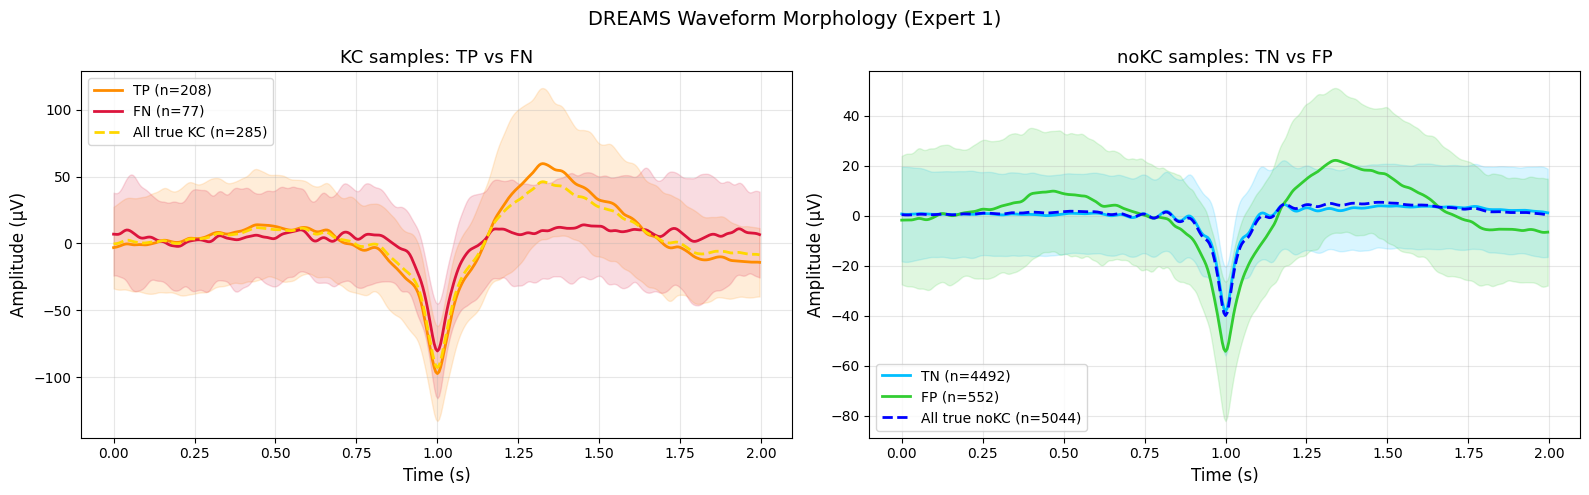

  TP: 208
  TN: 4492
  FP: 552
  FN: 77


In [55]:
# DREAMS internal morphology
plot_dreams_morphology(dreams_results_exp1, fs=200, criterion_name="Expert 1")

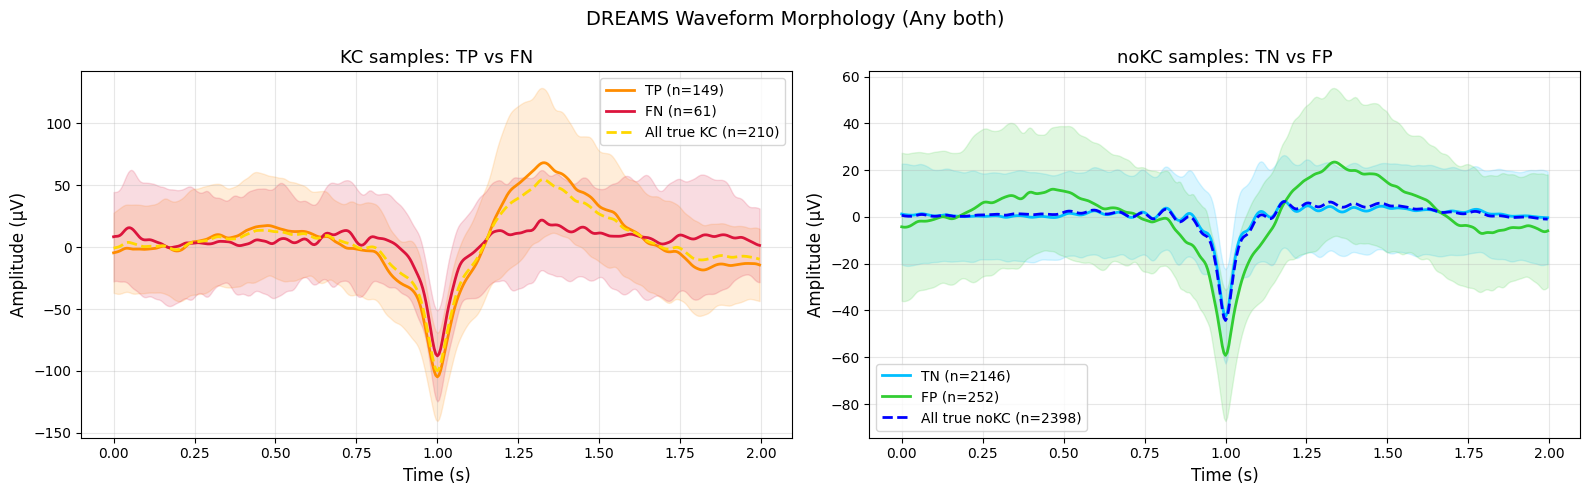

  TP: 149
  TN: 2146
  FP: 252
  FN: 61


In [56]:
plot_dreams_morphology(dreams_results_any, fs=200, criterion_name="Any both")

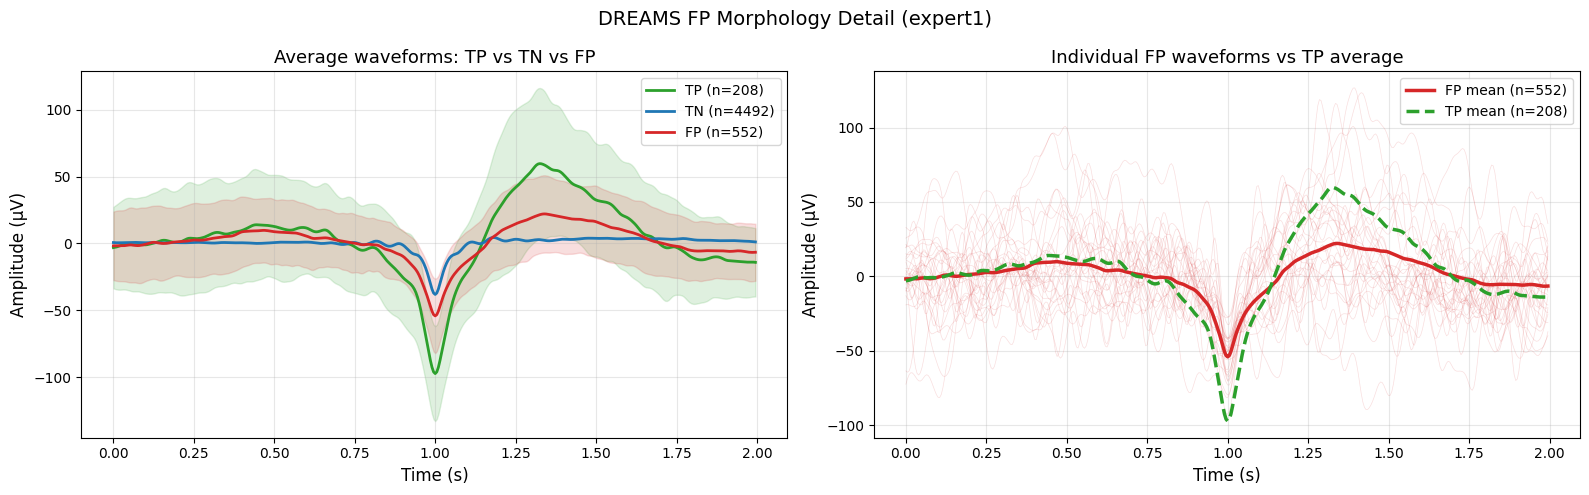

In [58]:
# FP detail (with Forcato dataset analysis)
plot_dreams_fp_detail(dreams_results_exp1, fs=200, criterion_name="expert1")
# plot_dreams_fp_detail(dreams_results_any, fs=200, criterion_name="any_both")

In [130]:
def plot_cross_dataset_comparison(df_original, df_dreams, fs=200, criterion_name=""):
    """
    Compare average KC and noKC waveforms between original and DREAMS datasets.

    Parameters
    ----------
    df_original : pd.DataFrame
        Original dataset with Flag, Label, Subject, etc.
    df_dreams : pd.DataFrame
        DREAMS dataset with Label, Subject, sample1..sample400.
    fs : int
        Sampling frequency.
    criterion_name : str
        Labeling criterion name for the title.
    """
    
    df = df_dreams.copy()
    df['outcome'] = 'unknown'
    df.loc[(df['Label'] == 'KC') & (df['y_pred'] == 'KC'), 'outcome'] = 'TP'
    df.loc[(df['Label'] == 'noKC') & (df['y_pred'] == 'noKC'), 'outcome'] = 'TN'
    df.loc[(df['Label'] == 'noKC') & (df['y_pred'] == 'KC'), 'outcome'] = 'FP'
    df.loc[(df['Label'] == 'KC') & (df['y_pred'] == 'noKC'), 'outcome'] = 'FN'
    df_dreams = df.copy()

    meta_cols_original = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    meta_cols_dreams = ['Subject', 'Label', 'y_pred', 'outcome']

    feature_cols_original = [c for c in df_original.columns if c not in meta_cols_original]
    feature_cols_dreams = [c for c in df_dreams.columns if c not in meta_cols_dreams]

    # Original: use Flag=1 only
    df_orig_model = df_original[df_original['Flag'] == 1]

    n_samples = len(feature_cols_original)
    time = np.arange(n_samples) / fs

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'External Evaluation ({criterion_name})', fontsize=14)

    # --- Left panel: KC comparison ---
    ax = axes[0]

    orig_kc = df_orig_model[df_orig_model['Label'] == 'KC']
    dreams_kc = df_dreams[df_dreams['Label'] == 'KC']
    
    dreams_FP = df_dreams[df_dreams['outcome'] == 'FP']
    dreams_FN = df_dreams[df_dreams['outcome'] == 'FN']

    if len(orig_kc) > 0:
        signals = orig_kc[feature_cols_original].values
        mean_sig = signals.mean(axis=0)
        std_sig = signals.std(axis=0)
        ax.plot(time, mean_sig, color="#FFD30F", linewidth=2,
                label=f'Forcato et al. 2020 KC (n={len(orig_kc)})')
        ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color='gold', alpha=0.15)

    if len(dreams_kc) > 0:
        signals = dreams_kc[feature_cols_dreams].values
        mean_sig = signals.mean(axis=0)
        std_sig = signals.std(axis=0)
        ax.plot(time, mean_sig, color='tab:red', linewidth=2,
                label=f'DREAMS KC (n={len(dreams_kc)})') 
        ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color='tab:red', alpha=0.15)
    
    signals = dreams_FP[feature_cols_dreams].values
    mean_sig = signals.mean(axis=0)
    std_sig = signals.std(axis=0)
    ax.plot(time, mean_sig, color='limegreen', linewidth=2,
                label=f'DREAMS FP (n={len(dreams_FP)})') 
    ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color='limegreen', alpha=0.15)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('KC waveforms: Forcato et al. 2020 vs DREAMS', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right panel: noKC comparison ---
    ax = axes[1]

    orig_nokc = df_orig_model[df_orig_model['Label'] == 'noKC']
    dreams_nokc = df_dreams[df_dreams['Label'] == 'noKC']

    if len(orig_nokc) > 0:
        signals = orig_nokc[feature_cols_original].values
        mean_sig = signals.mean(axis=0)
        std_sig = signals.std(axis=0)
        ax.plot(time, mean_sig, color='blue', linewidth=2,
                label=f'Forcato et al. 2020 noKC (n={len(orig_nokc)})')
        ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color='blue', alpha=0.15)

    if len(dreams_nokc) > 0:
        # Subsample noKC for visualization (too many)
        #n_plot = min(len(dreams_nokc), 1000)
        #rng = np.random.RandomState(42)
        #idx_sample = rng.choice(dreams_nokc.index, size=n_plot, replace=False)
        signals = df_dreams[feature_cols_dreams].values
        mean_sig = signals.mean(axis=0)
        std_sig = signals.std(axis=0)
        ax.plot(time, mean_sig, color="#00C3FF", linewidth=2, 
                label=f'DREAMS noKC (n={len(dreams_nokc)})')
        ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color='#00C3FF', alpha=0.15)

    signals = dreams_FN[feature_cols_dreams].values
    mean_sig = signals.mean(axis=0)
    std_sig = signals.std(axis=0)
    ax.plot(time, mean_sig, color="#008F70", linewidth=2, 
                label=f'DREAMS FN (n={len(dreams_FN)})')
    ax.fill_between(time, mean_sig - std_sig, mean_sig + std_sig,
                        color="#008F70", alpha=0.15)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('noKC waveforms: Forcato et al. 2020 vs DREAMS', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f'cross_dataset_comparison_{criterion_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

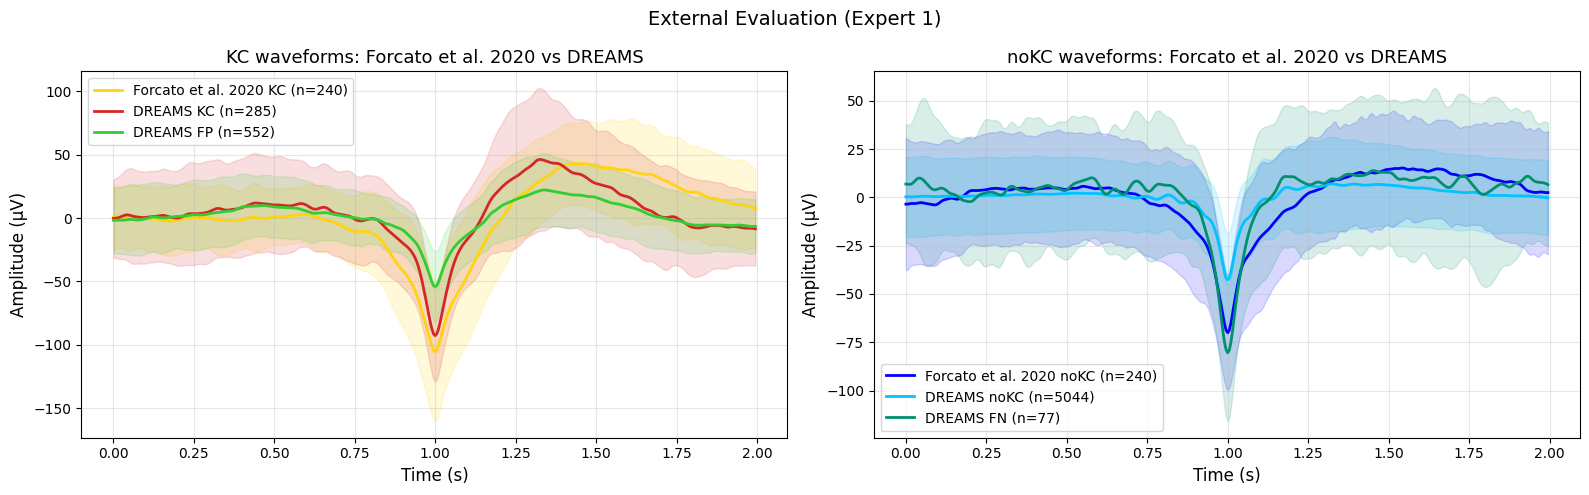

In [ ]:
# Cross-dataset comparison
plot_cross_dataset_comparison(df_original, dreams_results_exp1, fs=200, criterion_name="Expert 1")

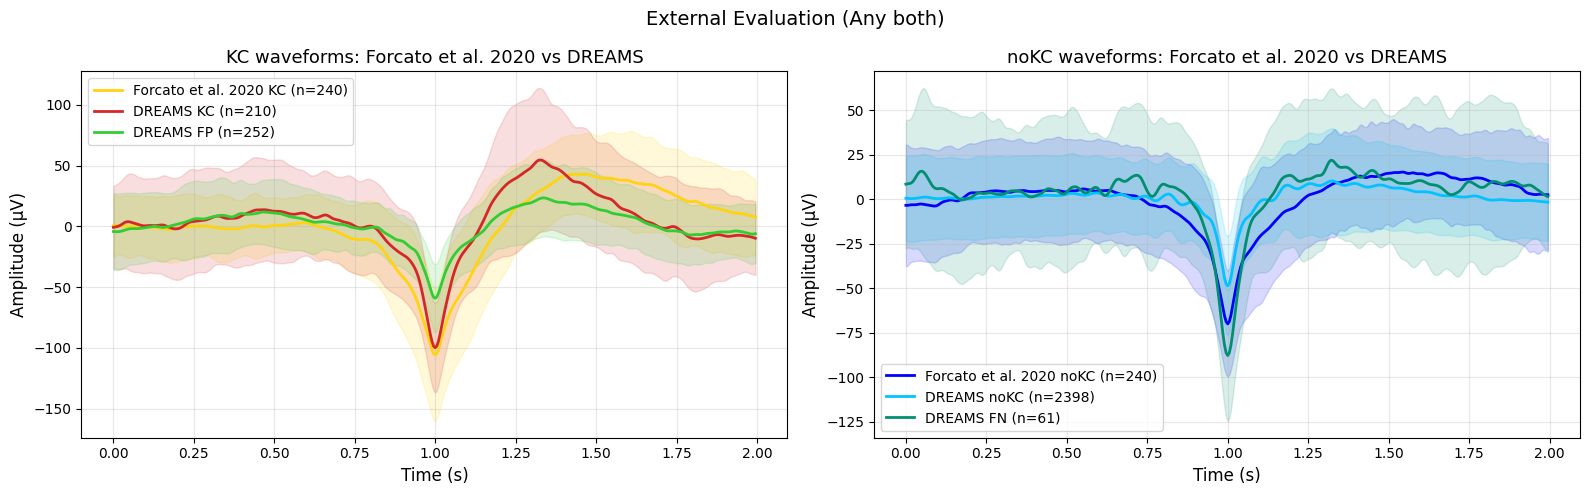

In [135]:
plot_cross_dataset_comparison(df_original, dreams_results_any, fs=200, criterion_name="Any both")

In [137]:
"""
Waveform Morphology: FP vs KC, FN vs noKC

Plots:
1. DREAMS internal:
   - FP mean vs KC mean vs noKC mean
   - FN mean vs noKC mean vs KC mean
2. Cross-dataset:
   - DREAMS FP vs Original KC vs DREAMS KC
   - DREAMS FN vs Original noKC vs DREAMS noKC
"""

def plot_dreams_internal(df_dreams_results, fs=200, criterion_name=""):
    """
    DREAMS internal morphology analysis.

    Left panel:  FP mean vs real KC mean vs real noKC mean
    Right panel: FN mean vs real noKC mean vs real KC mean

    Parameters
    ----------
    df_dreams_results : pd.DataFrame
        DREAMS data with Label, y_pred, and signal features.
    fs : int
        Sampling frequency.
    criterion_name : str
        Labeling criterion name for the title.
    """
    meta_cols = ['Subject', 'Label', 'y_pred']
    feature_cols = [c for c in df_dreams_results.columns if c not in meta_cols]

    df = df_dreams_results
    n_samples = len(feature_cols)
    time = np.arange(n_samples) / fs

    # Extract signals by category
    kc_all = df[df['Label'] == 'KC'][feature_cols].values
    nokc_all = df[df['Label'] == 'noKC'][feature_cols].values
    fp = df[(df['Label'] == 'noKC') & (df['y_pred'] == 'KC')][feature_cols].values
    fn = df[(df['Label'] == 'KC') & (df['y_pred'] == 'noKC')][feature_cols].values

    n_fp = len(fp)
    n_fn = len(fn)
    n_kc = len(kc_all)
    n_nokc = len(nokc_all)

    mean_kc = kc_all.mean(axis=0) if n_kc > 0 else np.zeros(n_samples)
    mean_nokc = nokc_all.mean(axis=0) if n_nokc > 0 else np.zeros(n_samples)
    mean_fp = fp.mean(axis=0) if n_fp > 0 else np.zeros(n_samples)
    mean_fn = fn.mean(axis=0) if n_fn > 0 else np.zeros(n_samples)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'DREAMS Internal Evaluation ({criterion_name})', fontsize=14)

    # --- Left: FP vs real KC vs real noKC ---
    ax = axes[0]
    ax.plot(time, mean_kc, color='tab:red', linewidth=2, linestyle='--',
            label=f'All true KC (n={n_kc})') #True noKC #00C3FF , FN #008F70, True KC tab:red , FP limegreen
    ax.fill_between(time, mean_kc - kc_all.std(axis=0), mean_kc + kc_all.std(axis=0),
                    color='tab:red', alpha=0.1)
    ax.plot(time, mean_nokc, color='#00C3FF', linewidth=2, linestyle='--',
            label=f'All true noKC (n={n_nokc})')
    ax.fill_between(time, mean_nokc - nokc_all.std(axis=0),
                    mean_nokc + nokc_all.std(axis=0),
                    color='#00C3FF', alpha=0.1)
    ax.plot(time, mean_fp, color='limegreen', linewidth=2.5,
            label=f'False Positive (n={n_fp})')
    if n_fp > 0:
        ax.fill_between(time, mean_fp - fp.std(axis=0), mean_fp + fp.std(axis=0),
                        color='limegreen', alpha=0.1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('DREAMS: All true KC vs All true noKC vs FP', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right: FN vs real noKC vs real KC ---
    ax = axes[1]
    ax.plot(time, mean_kc, color='tab:red', linewidth=2, linestyle='--',
            label=f'All true KC (n={n_kc})')
    ax.fill_between(time, mean_kc - kc_all.std(axis=0), mean_kc + kc_all.std(axis=0),
                    color='tab:red', alpha=0.1)
    ax.plot(time, mean_nokc, color='#00C3FF', linewidth=2, linestyle='--',
            label=f'All true noKC (n={n_nokc})')
    ax.fill_between(time, mean_nokc - nokc_all.std(axis=0),
                    mean_nokc + nokc_all.std(axis=0),
                    color='#00C3FF', alpha=0.1)
    ax.plot(time, mean_fn, color='#008F70', linewidth=2.5,
            label=f'False Negative (n={n_fn})')
    if n_fn > 0:
        ax.fill_between(time, mean_fn - fn.std(axis=0), mean_fn + fn.std(axis=0),
                        color='#008F70', alpha=0.1)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('DREAMS: All true KC vs All true noKC vs FN', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig(f'dreams_internal_morphology_{criterion_name}.png',
    #             dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  KC: {n_kc}, noKC: {n_nokc}, FP: {n_fp}, FN: {n_fn}")


def plot_cross_dataset_errors(df_original, df_dreams_results, fs=200,
                               criterion_name=""):
    """
    Cross-dataset error morphology.

    Left panel:  DREAMS FP vs Original KC vs DREAMS KC
    Right panel: DREAMS FN vs Original noKC vs DREAMS noKC

    Parameters
    ----------
    df_original : pd.DataFrame
        Original dataset with Flag, Label, Subject, CG, LG, etc.
    df_dreams_results : pd.DataFrame
        DREAMS data with Label, y_pred, and signal features.
    fs : int
        Sampling frequency.
    criterion_name : str
        Labeling criterion name for the title.
    """
    meta_cols_original = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    meta_cols_dreams = ['Subject', 'Label', 'y_pred']

    feature_cols_orig = [c for c in df_original.columns if c not in meta_cols_original]
    feature_cols_dreams = [c for c in df_dreams_results.columns
                           if c not in meta_cols_dreams]

    df_orig_model = df_original[df_original['Flag'] == 1]
    df = df_dreams_results

    n_samples = len(feature_cols_orig)
    time = np.arange(n_samples) / fs

    # Original dataset signals
    orig_kc = df_orig_model[df_orig_model['Label'] == 'KC'][feature_cols_orig].values
    orig_nokc = df_orig_model[df_orig_model['Label'] == 'noKC'][feature_cols_orig].values

    # DREAMS signals
    dreams_kc = df[df['Label'] == 'KC'][feature_cols_dreams].values
    dreams_nokc = df[df['Label'] == 'noKC'][feature_cols_dreams].values
    dreams_fp = df[(df['Label'] == 'noKC') & (df['y_pred'] == 'KC')][feature_cols_dreams].values
    dreams_fn = df[(df['Label'] == 'KC') & (df['y_pred'] == 'noKC')][feature_cols_dreams].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Cross-Dataset Error Morphology ({criterion_name})', fontsize=14)

    # --- Left: DREAMS FP vs Original KC vs DREAMS KC ---
    ax = axes[0]
    if len(orig_kc) > 0:
        mean_orig_kc = orig_kc.mean(axis=0)
        ax.plot(time, mean_orig_kc, color='tab:green', linewidth=2,
                label=f'Original KC (n={len(orig_kc)})')
        ax.fill_between(time, mean_orig_kc - orig_kc.std(axis=0),
                        mean_orig_kc + orig_kc.std(axis=0),
                        color='tab:green', alpha=0.1)

    if len(dreams_kc) > 0:
        mean_dreams_kc = dreams_kc.mean(axis=0)
        ax.plot(time, mean_dreams_kc, color='tab:cyan', linewidth=2,
                label=f'DREAMS KC (n={len(dreams_kc)})')

    if len(dreams_fp) > 0:
        mean_fp = dreams_fp.mean(axis=0)
        ax.plot(time, mean_fp, color='tab:red', linewidth=2.5, linestyle='--',
                label=f'DREAMS FP (n={len(dreams_fp)})')
        ax.fill_between(time, mean_fp - dreams_fp.std(axis=0),
                        mean_fp + dreams_fp.std(axis=0),
                        color='tab:red', alpha=0.1)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('DREAMS FP vs KC (Original & DREAMS)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right: DREAMS FN vs Original noKC vs DREAMS noKC ---
    ax = axes[1]
    if len(orig_nokc) > 0:
        mean_orig_nokc = orig_nokc.mean(axis=0)
        ax.plot(time, mean_orig_nokc, color='tab:blue', linewidth=2,
                label=f'Original noKC (n={len(orig_nokc)})')
        ax.fill_between(time, mean_orig_nokc - orig_nokc.std(axis=0),
                        mean_orig_nokc + orig_nokc.std(axis=0),
                        color='tab:blue', alpha=0.1)

    if len(dreams_nokc) > 0:
        # Subsample for visualization
        rng = np.random.RandomState(42)
        n_plot = min(len(dreams_nokc), 1000)
        idx = rng.choice(len(dreams_nokc), size=n_plot, replace=False)
        mean_dreams_nokc = dreams_nokc.mean(axis=0)
        ax.plot(time, mean_dreams_nokc, color='tab:purple', linewidth=2,
                label=f'DREAMS noKC (n={len(dreams_nokc)})')

    if len(dreams_fn) > 0:
        mean_fn = dreams_fn.mean(axis=0)
        ax.plot(time, mean_fn, color='tab:orange', linewidth=2.5, linestyle='--',
                label=f'DREAMS FN (n={len(dreams_fn)})')
        ax.fill_between(time, mean_fn - dreams_fn.std(axis=0),
                        mean_fn + dreams_fn.std(axis=0),
                        color='tab:orange', alpha=0.1)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('DREAMS FN vs noKC (Original & DREAMS)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f'cross_dataset_errors_{criterion_name}.png',
    #            dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Original: KC={len(orig_kc)}, noKC={len(orig_nokc)}")
    print(f"  DREAMS: KC={len(dreams_kc)}, noKC={len(dreams_nokc)}, "
          f"FP={len(dreams_fp)}, FN={len(dreams_fn)}")

In [43]:
# Get out-of-fold predictions
dreams_results_exp1 = get_oof_predictions_dreams(results['expert1']['df'], ratio=3.0)
dreams_results_any = get_oof_predictions_dreams(results['any_both']['df'], ratio=3.0)

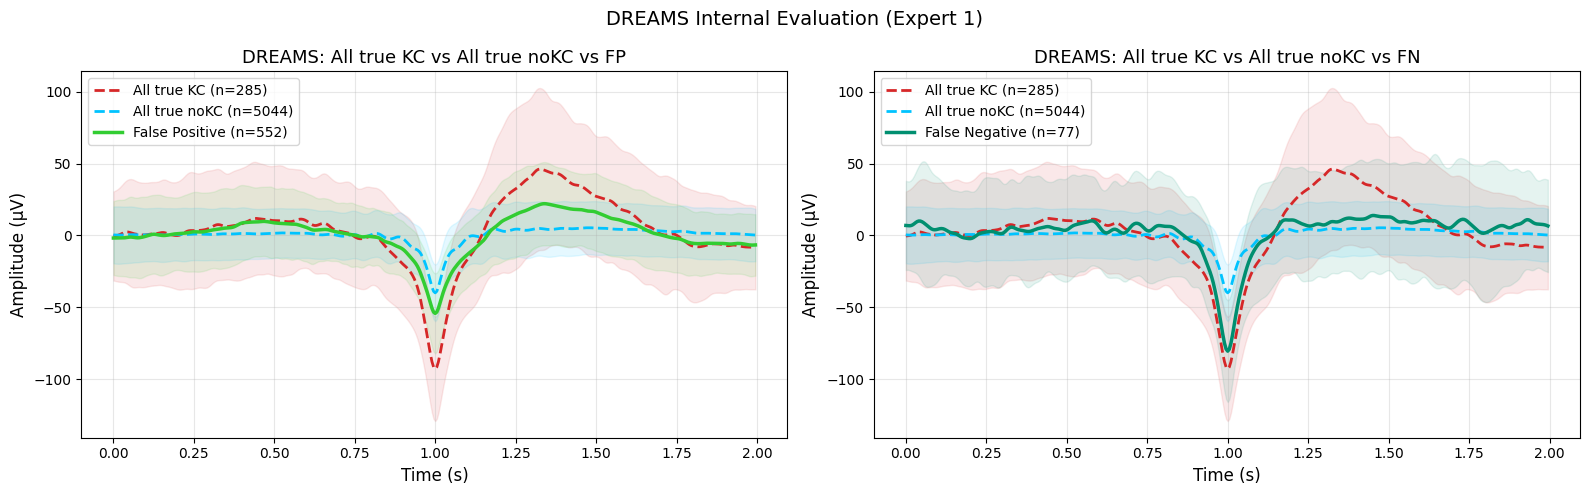

  KC: 285, noKC: 5044, FP: 552, FN: 77


In [138]:
# DREAMS internal — FP vs KC, FN vs noKC
plot_dreams_internal(dreams_results_exp1, fs=200, criterion_name="Expert 1")

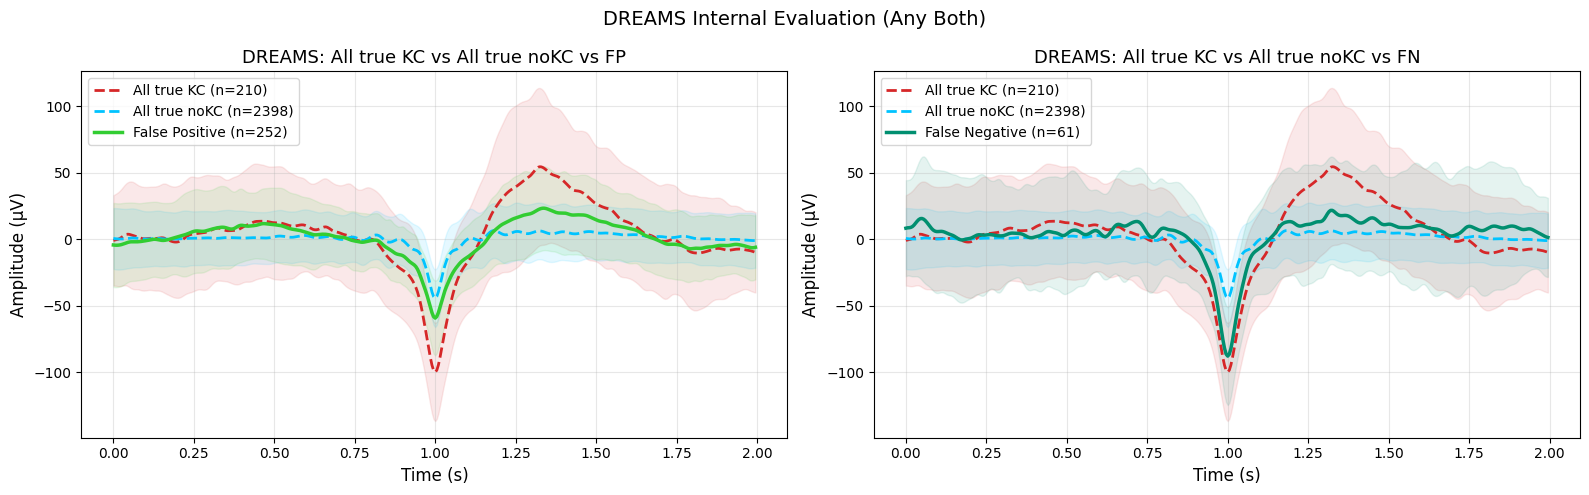

  KC: 210, noKC: 2398, FP: 252, FN: 61


In [139]:
plot_dreams_internal(dreams_results_any, fs=200, criterion_name="Any Both")

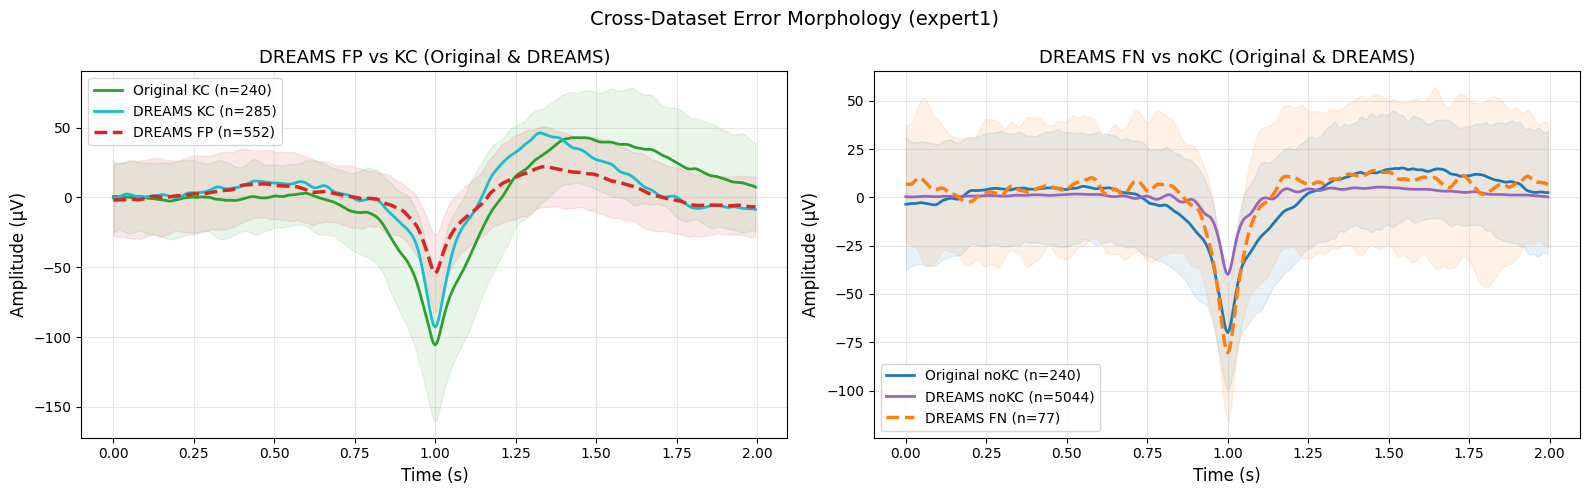

  Original: KC=240, noKC=240
  DREAMS: KC=285, noKC=5044, FP=552, FN=77


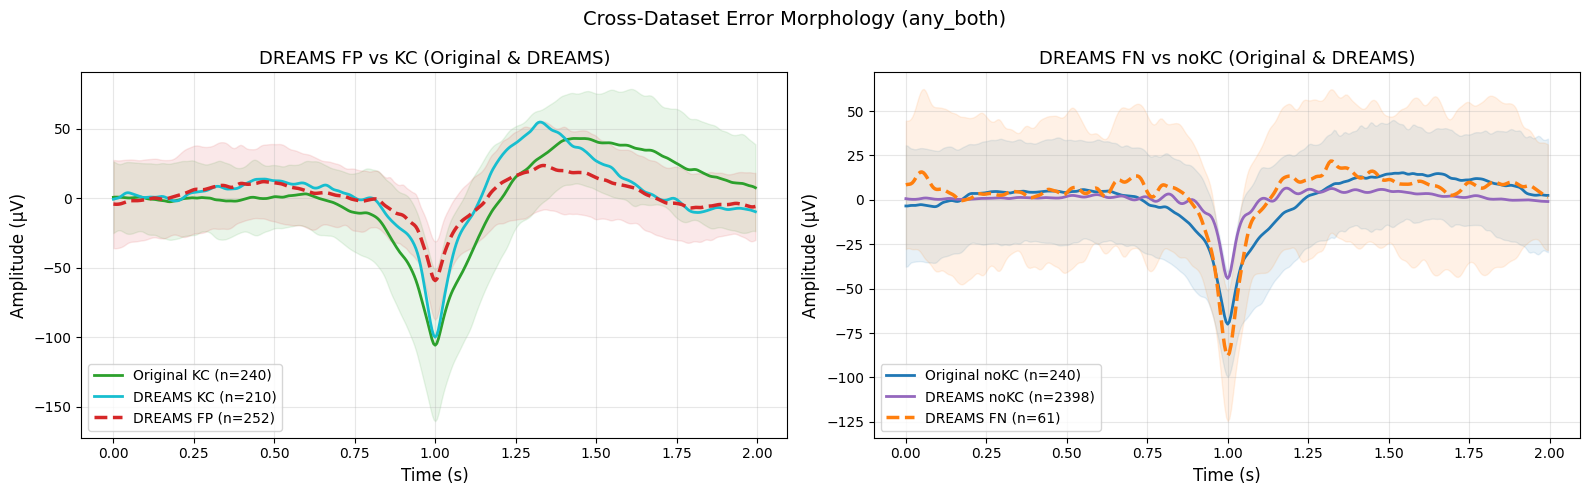

  Original: KC=240, noKC=240
  DREAMS: KC=210, noKC=2398, FP=252, FN=61


In [45]:
# Cross-dataset — DREAMS errors vs original dataset waveforms
plot_cross_dataset_errors(df_original, dreams_results_exp1, fs=200, criterion_name="expert1")
plot_cross_dataset_errors(df_original, dreams_results_any, fs=200, criterion_name="any_both")